import de librerias

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

Datos OCR Crudos

In [2]:
datos_ocr_crudos = [
    {"texto":"FARMACIA CENTRAL","confianza":0.99,"y":10,"x":100},

    {"texto":"1","confianza":0.98,"y":100,"x":20},
    {"texto":"Paracetamol","confianza":0.95,"y":100,"x":100},
    {"texto":"2500.00","confianza":0.97,"y":100,"x":300},
    {"texto":"2500.00","confianza":0.96,"y":100,"x":450},

    {"texto":"2","confianza":0.97,"y":130,"x":20},
    {"texto":"Vitamina C","confianza":0.93,"y":130,"x":100},
    {"texto":"1800.00","confianza":0.95,"y":130,"x":300},
    {"texto":"3600.00","confianza":0.94,"y":130,"x":450},

    {"texto":"TOTAL","confianza":0.99,"y":220,"x":350},
    {"texto":"6100.00","confianza":0.98,"y":220,"x":500}
]

Creacion del DataFrame

In [3]:
df_raw = pd.DataFrame(datos_ocr_crudos)

display(df_raw)

,texto,confianza,y,x
0,FARMACIA CENTRAL,0.99,10,100
1,1,0.98,100,20
2,Paracetamol,0.95,100,100
3,2500.00,0.97,100,300
4,2500.00,0.96,100,450
5,2,0.97,130,20
6,Vitamina C,0.93,130,100
7,1800.00,0.95,130,300
8,3600.00,0.94,130,450
9,TOTAL,0.99,220,350


Filtramos por confianza

In [4]:
df_filtered = df_raw[df_raw['confianza'] >= 0.90].copy()

display(df_filtered)

,texto,confianza,y,x
0,FARMACIA CENTRAL,0.99,10,100
1,1,0.98,100,20
2,Paracetamol,0.95,100,100
3,2500.00,0.97,100,300
4,2500.00,0.96,100,450
5,2,0.97,130,20
6,Vitamina C,0.93,130,100
7,1800.00,0.95,130,300
8,3600.00,0.94,130,450
9,TOTAL,0.99,220,350


Aislamos los productos

In [5]:
df_productos = df_filtered[

    (df_filtered['y'] >= 90) &

    (df_filtered['y'] < 200)

].copy()

print("--- SOLO ZONA DE PRODUCTOS ---")

display(df_productos)

--- SOLO ZONA DE PRODUCTOS ---


,texto,confianza,y,x
1,1,0.98,100,20
2,Paracetamol,0.95,100,100
3,2500.00,0.97,100,300
4,2500.00,0.96,100,450
5,2,0.97,130,20
6,Vitamina C,0.93,130,100
7,1800.00,0.95,130,300
8,3600.00,0.94,130,450


Agrupar textos por fila usando coordenada Y

In [6]:
df_productos = df_productos.sort_values(
    by='y'
).reset_index(drop=True)
df_productos = df_productos.sort_values(by='y').reset_index(drop=True)

fila_ids = []

current_fila_id = 0

y_tolerance = 7

if not df_productos.empty:

    fila_ids.append(current_fila_id)

    for i in range(1, len(df_productos)):

        if df_productos.loc[i, 'y'] - df_productos.loc[i-1, 'y'] > y_tolerance:

            current_fila_id += 1

        fila_ids.append(current_fila_id)

df_productos['fila_id'] = fila_ids

print("--- PRODUCTOS AGRUPADOS POR FILA ---")

display(df_productos[['texto', 'confianza', 'y', 'x', 'fila_id']])
fila_ids = []

current_fila_id = 0

y_tolerance = 5

--- PRODUCTOS AGRUPADOS POR FILA ---


,texto,confianza,y,x,fila_id
0,1,0.98,100,20,0
1,Paracetamol,0.95,100,100,0
2,2500.00,0.97,100,300,0
3,2500.00,0.96,100,450,0
4,2,0.97,130,20,1
5,Vitamina C,0.93,130,100,1
6,1800.00,0.95,130,300,1
7,3600.00,0.94,130,450,1


Reconstruir tabla usando coordenada X

In [7]:
productos_limpios = []

for idx, grupo in df_productos.groupby('fila_id'):

    grupo_ordenado = grupo.sort_values(by='x').reset_index(drop=True)

    cantidad = ""

    descripcion = ""

    precio_unitario = ""

    precio_total = ""

    for _, row in grupo_ordenado.iterrows():

        if row['x'] <= 50:

            cantidad = row['texto']

        elif 50 < row['x'] <= 250:

            descripcion = row['texto']

        elif 250 < row['x'] <= 380:

            precio_unitario = row['texto']

        elif row['x'] > 380:

            precio_total = row['texto']

    productos_limpios.append({

        "Cantidad": cantidad,

        "Descripcion": descripcion,

        "Precio_Unitario": precio_unitario,

        "Precio_Total": precio_total

    })

df_invoice = pd.DataFrame(productos_limpios)

print("--- TABLA RECONSTRUIDA ---")

display(df_invoice)

--- TABLA RECONSTRUIDA ---


,Cantidad,Descripcion,Precio_Unitario,Precio_Total
0,1,Paracetamol,2500.00,2500.00
1,2,Vitamina C,1800.00,3600.00


Normalizacion y conversion de tipos de datos

In [8]:
df_invoice['Cantidad'] = df_invoice['Cantidad'].replace('', '0')

df_invoice['Precio_Unitario'] = df_invoice['Precio_Unitario'].str.replace('#', '0')

df_invoice['Precio_Total'] = df_invoice['Precio_Total'].str.replace('#', '0')

df_invoice['Cantidad'] = df_invoice['Cantidad'].astype(int)

df_invoice['Precio_Unitario'] = df_invoice['Precio_Unitario'].astype(float)

df_invoice['Precio_Total'] = df_invoice['Precio_Total'].astype(float)

print("--- DATOS NORMALIZADOS ---")

display(df_invoice)

print("--- INFORMACIÓN DEL DATAFRAME ---")

df_invoice.info()


--- DATOS NORMALIZADOS ---


,Cantidad,Descripcion,Precio_Unitario,Precio_Total
0,1,Paracetamol,2500.0,2500.0
1,2,Vitamina C,1800.0,3600.0


--- INFORMACIÓN DEL DATAFRAME ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cantidad         2 non-null      int64  
 1   Descripcion      2 non-null      object 
 2   Precio_Unitario  2 non-null      float64
 3   Precio_Total     2 non-null      float64
dtypes: float64(2), int64(1), object(1)
memory usage: 196.0+ bytes


Guardar datos limpios

In [9]:
df_invoice.to_csv('ticket_farmacia_limpio.csv', index=False)

Analisis exploratorio de datos

In [10]:
print("--- MÉTRICAS DESCRIPTIVAS ---")

total_articulos = df_invoice['Cantidad'].sum()

precio_promedio = df_invoice['Precio_Unitario'].mean()

total_facturado = df_invoice['Precio_Total'].sum()

producto_mayor_gasto = df_invoice.loc[df_invoice['Precio_Total'].idxmax(), 'Descripcion']

print(f"Total de artículos comprados: {total_articulos}")

print(f"Precio unitario promedio: {precio_promedio}")

print(f"Total facturado: {total_facturado}")

print(f"Producto con mayor gasto: {producto_mayor_gasto}")



--- MÉTRICAS DESCRIPTIVAS ---
Total de artículos comprados: 3
Precio unitario promedio: 2150.0
Total facturado: 6100.0
Producto con mayor gasto: Vitamina C


Visualizacion

/var/folders/jg/7_40s2d55_v35jrt9dbwp1600000gn/T/ipykernel_3539/2318285006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


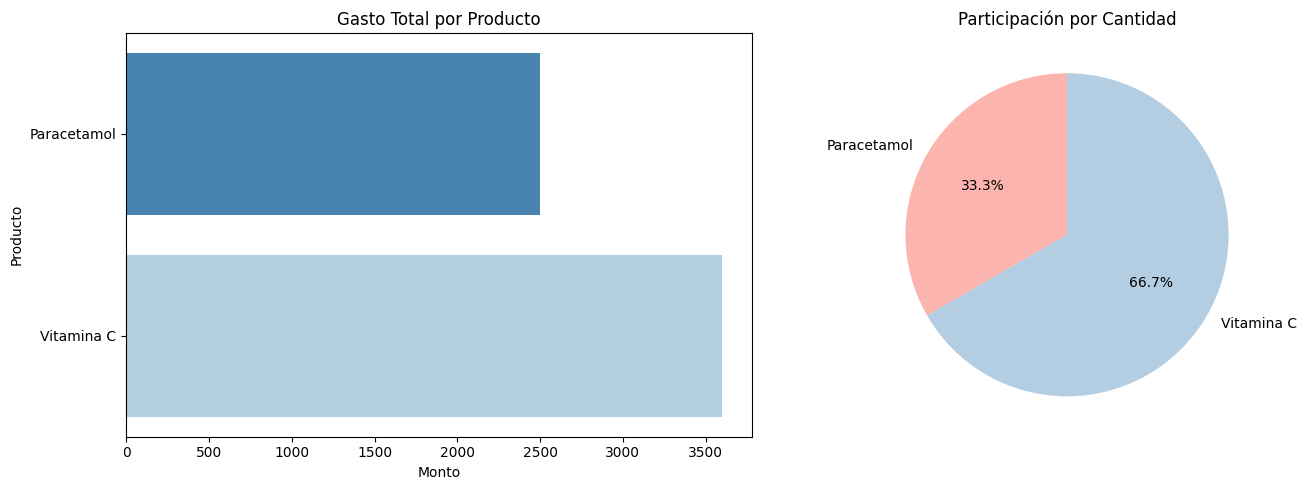

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(

    data=df_invoice,

    x='Precio_Total',

    y='Descripcion',

    ax=ax[0],

    palette='Blues_r'

)

ax[0].set_title('Gasto Total por Producto')

ax[0].set_xlabel('Monto')

ax[0].set_ylabel('Producto')

ax[1].pie(

    df_invoice['Cantidad'],

    labels=df_invoice['Descripcion'],

    autopct='%1.1f%%',

    startangle=90,

    colors=sns.color_palette('Pastel1')

)

ax[1].set_title('Participación por Cantidad')

plt.tight_layout()

plt.show()

Conclusión

In [13]:
print("--- CONCLUSIÓN ---")

print("En este ejercicio se reconstruyó una tabla de productos a partir de datos crudos generados por OCR.")

print("Primero se convirtieron los datos en un DataFrame, luego se filtraron lecturas de baja confianza,")

print("se aislaron los productos mediante coordenadas, se agruparon los textos por fila y se reconstruyó la tabla.")

print("Finalmente, se normalizaron los tipos de datos, se calcularon métricas descriptivas y se visualizaron los resultados.")

--- CONCLUSIÓN ---
En este ejercicio se reconstruyó una tabla de productos a partir de datos crudos generados por OCR.
Primero se convirtieron los datos en un DataFrame, luego se filtraron lecturas de baja confianza,
se aislaron los productos mediante coordenadas, se agruparon los textos por fila y se reconstruyó la tabla.
Finalmente, se normalizaron los tipos de datos, se calcularon métricas descriptivas y se visualizaron los resultados.


In [ ]:
productos_limpios = []

for idx, grupo in df_productos.groupby('fila_id'):

    grupo_ordenado = grupo.sort_values(by='x').reset_index(drop=True)

    cantidad = ""

    descripcion = ""

    precio_unitario = ""

    precio_total = ""

    for _, row in grupo_ordenado.iterrows():

        if row['x'] <= 50:

            cantidad = row['texto']

        elif 50 < row['x'] <= 250:

            descripcion = row['texto']

        elif 250 < row['x'] <= 380:

            precio_unitario = row['texto']

        elif row['x'] > 380:

            precio_total = row['texto']

    productos_limpios.append({

        "Cantidad": cantidad,

        "Descripcion": descripcion,

        "Precio_Unitario": precio_unitario,

        "Precio_Total": precio_total

    })

df_invoice = pd.DataFrame(productos_limpios)

print("--- TABLA RECONSTRUIDA ---")

display(df_invoice)

--- TABLA RECONSTRUIDA ---


,Cantidad,Descripcion,Precio_Unitario,Precio_Total
0,1,Paracetamol,2500.00,2500.00
1,2,Vitamina C,1800.00,3600.00
